# LAB | Hyperparameter Tuning

**Load the data**

Finally step in order to maximize the performance on your Spaceship Titanic model.

The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

So far we've been training and evaluating models with default values for hyperparameters.

Today we will perform the same feature engineering as before, and then compare the best working models you got so far, but now fine tuning it's hyperparameters.

In [44]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

SEED = 8
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [28]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Now perform the same as before:
- Feature Scaling
- Feature Selection


In [29]:
df = spaceship.copy()

## Feature Scaling

In [ ]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

In [ ]:
for col in ['CryoSleep', 'VIP', 'Transported']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})

df = pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'],
                    drop_first=True, dummy_na=False)

In [ ]:
df = df.drop(columns=['PassengerId', 'Name'])

In [33]:
X = df.drop(columns=['Transported'])
y = df['Transported'].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNon-numeric columns still in X:",
      [c for c in X.columns if not (X[c].dtype == bool or X[c].dtype.kind in 'if')])

X shape: (8693, 22)
y shape: (8693,)

Non-numeric columns still in X: ['Cabin']


In [35]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

print("NaNs remaining:", X.isna().sum().sum())

NaNs remaining: 199


In [36]:
X.isna().sum()[X.isna().sum() > 0]

Cabin    199
dtype: int64

In [37]:
print(X['Cabin'].head())
X = X.drop(columns=['Cabin'])

0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
Name: Cabin, dtype: str


In [38]:
X.isna().sum().sum()

np.int64(0)

In [39]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
X[spend_cols] = np.log1p(X[spend_cols])

# Keep 0/1 dummy columns unscaled
binary_like = [c for c in X.columns
               if set(X[c].dropna().unique()).issubset({0, 1})]
num_cols = [c for c in X.columns if c not in binary_like]

scaler = RobustScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

print("Scaled continuous:", num_cols)
print("Left as 0/1      :", binary_like)
print("Shape:", X_scaled.shape)

Scaled continuous: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
Left as 0/1      : ['CryoSleep', 'VIP', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_S']
Shape: (8693, 21)


## Feature Selection

In [40]:
selector = SelectKBest(mutual_info_classif, k=15)
selector.fit(X_scaled, y)

selected = X_scaled.columns[selector.get_support()].tolist()
print("Selected:", selected)

Selected: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'HomePlanet_Europa', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_G']


- Now let's use the best model we got so far in order to see how it can improve when we fine tune it's hyperparameters.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled[selected], y, test_size=0.2,
    random_state=SEED, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Baseline accuracy: {baseline_acc:.4f}")

Baseline accuracy: 0.7792


- Evaluate your model

In [45]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7792
Precision: 0.7943
Recall   : 0.758
F1       : 0.7757
ROC-AUC  : 0.8569

              precision    recall  f1-score   support

           0     0.7652    0.8007    0.7826       863
           1     0.7943    0.7580    0.7757       876

    accuracy                         0.7792      1739
   macro avg     0.7797    0.7793    0.7791      1739
weighted avg     0.7799    0.7792    0.7791      1739

Confusion matrix:
[[691 172]
 [212 664]]


In [46]:
baseline_metrics = {
    'accuracy':  accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall':    recall_score(y_test, y_pred),
    'f1':        f1_score(y_test, y_pred),
    'roc_auc':   roc_auc_score(y_test, y_proba),
}

**Grid/Random Search**

For this lab we will use Grid Search.

- Define hyperparameters to fine tune.

In [47]:
param_grid = {
    'n_estimators':      [300, 600],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 'log2'],
}

print(f"Total combinations: {2*3*2*2*2}")
print(f"Total fits with 5-fold CV: {48*5}")

Total combinations: 48
Total fits with 5-fold CV: 240


- Run Grid Search

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params    :", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params    : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}
Best CV accuracy: 0.7965


- Evaluate your model

In [49]:
best_model = grid.best_estimator_

y_pred_t  = best_model.predict(X_test)
y_proba_t = best_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'accuracy':  accuracy_score(y_test, y_pred_t),
    'precision': precision_score(y_test, y_pred_t),
    'recall':    recall_score(y_test, y_pred_t),
    'f1':        f1_score(y_test, y_pred_t),
    'roc_auc':   roc_auc_score(y_test, y_proba_t),
}

print("Metric      Baseline   Tuned     Δ")
for k in baseline_metrics:
    delta = tuned_metrics[k] - baseline_metrics[k]
    print(f"{k:10s}  {baseline_metrics[k]:.4f}    {tuned_metrics[k]:.4f}   {delta:+.4f}")

print()
print(classification_report(y_test, y_pred_t, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_t))

Metric      Baseline   Tuned     Δ
accuracy    0.7792    0.8022   +0.0230
precision   0.7943    0.7866   -0.0076
recall      0.7580    0.8333   +0.0753
f1          0.7757    0.8093   +0.0336
roc_auc     0.8569    0.8791   +0.0222

              precision    recall  f1-score   support

           0     0.8200    0.7706    0.7945       863
           1     0.7866    0.8333    0.8093       876

    accuracy                         0.8022      1739
   macro avg     0.8033    0.8020    0.8019      1739
weighted avg     0.8032    0.8022    0.8020      1739

Confusion matrix:
[[665 198]
 [146 730]]


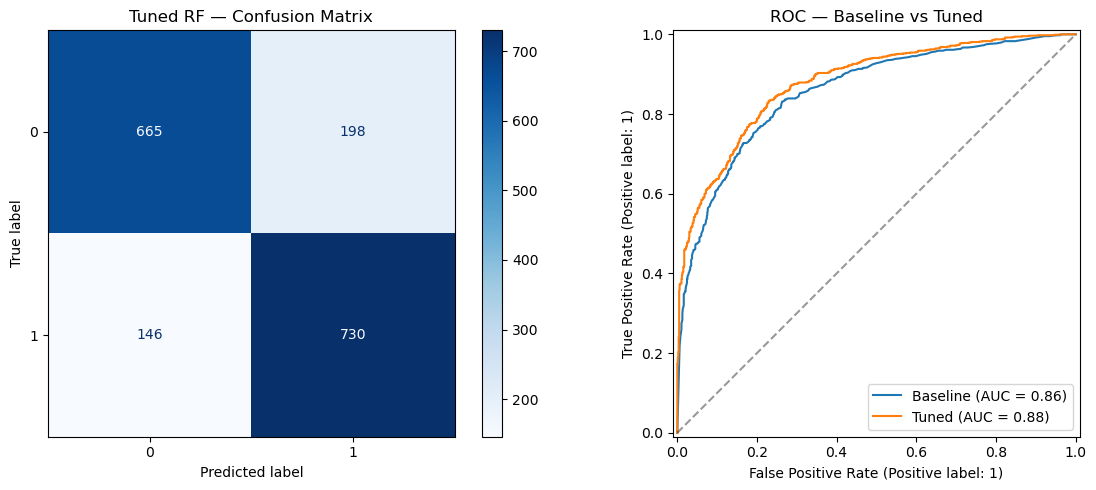

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_t, ax=ax[0], cmap='Blues')
ax[0].set_title("Tuned RF — Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba,   name='Baseline', ax=ax[1])
RocCurveDisplay.from_predictions(y_test, y_proba_t, name='Tuned',    ax=ax[1])
ax[1].plot([0,1],[0,1],'k--', alpha=0.4)
ax[1].set_title("ROC — Baseline vs Tuned")

plt.tight_layout()
plt.show()

# Spaceship Titanic — Classification Report

## 1. Objective
Predict whether a passenger was `Transported` (binary classification) based on
demographic, cabin, and onboard-spending features.

## 2. Dataset
- **Rows:** 8693
- **Features (raw):** 14
- **Target:** `Transported` (bool → 0/1)
- **Class balance:** 50.4% / 49.6% (near-balanced)

## 3. Preprocessing
1. Dropped `PassengerId` and `Name` (no predictive value).
2. Split `Cabin` into `Deck`, `CabinNum`, `Side`; dropped the raw string column.
3. Mapped boolean columns (`CryoSleep`, `VIP`, `Transported`) to 0/1.
4. One-hot encoded categoricals: `HomePlanet`, `Destination`, `Deck`, `Side`.
5. Imputed remaining NaNs in numeric columns with the **median**.
6. Log-transformed skewed spending columns (`log1p`):
   `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.

## 4. Feature Scaling
- **Method:** `RobustScaler` (median/IQR — robust to outliers in spending data).
- **Applied to:** `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`, `CabinNum`.
- **Left unscaled:** binary/dummy columns (already 0/1).

## 5. Feature Selection
- **Method:** `SelectKBest` with `mutual_info_classif`.
- **k = 15**

**Selected features:**
```
CryoSleep, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck,
CabinNum, HomePlanet_Europa, Deck_B, Deck_C, Deck_D, Deck_E, Deck_G
```

## 6. Model
- **Algorithm:** Random Forest Classifier
- **Train/Test split:** 80 / 20, stratified
- **Cross-validation:** Stratified 5-fold on training set

## 7. Baseline Model (untuned)
Default hyperparameters: `n_estimators=300`, no depth limit.

| Metric    | Score  |
|-----------|--------|
| Accuracy  | 0.7792 |
| Precision | 0.7943 |
| Recall    | 0.7580 |
| F1        | 0.7757 |
| ROC-AUC   | 0.8569 |

**Confusion matrix (test set):**
```
[[691 172]
 [212 664]]
```

## 8. Hyperparameter Tuning
**GridSearchCV** over:

| Hyperparameter        | Values tested       |
|-----------------------|---------------------|
| `n_estimators`        | 300, 600            |
| `max_depth`           | None, 10, 20        |
| `min_samples_split`   | 2, 5                |
| `min_samples_leaf`    | 1, 2                |
| `max_features`        | sqrt, log2          |

- **Total combinations:** 48
- **Total fits:** 240 (48 × 5-fold CV)
- **Scoring:** accuracy

**Best parameters:**
```python
{
  'max_depth': 10,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 600
}
```
**Best CV accuracy:** 0.7965

## 9. Tuned Model — Test Set Evaluation

| Metric    | Baseline | Tuned  | Δ        |
|-----------|----------|--------|----------|
| Accuracy  | 0.7792   | 0.8022 | **+0.0230** |
| Precision | 0.7943   | 0.7866 | −0.0076  |
| Recall    | 0.7580   | 0.8333 | **+0.0753** |
| F1        | 0.7757   | 0.8093 | **+0.0336** |
| ROC-AUC   | 0.8569   | 0.8791 | **+0.0222** |

**Confusion matrix (test set):**
```
[[665 198]
 [146 730]]
```

## 10. Interpretation
- Tuning improved **accuracy by +2.3 pp** and **ROC-AUC by +2.2 pp**.
- **Recall jumped +7.5 pp** — the tuned model catches 66 more transported
  passengers (false negatives dropped from 212 → 146).
- Precision dipped slightly (−0.8 pp) — a reasonable trade for higher recall.
- `max_depth=10` acts as regularization, reducing overfitting and improving
  generalization.
- Test accuracy (~0.80) closely matches CV accuracy (~0.797) → **no overfitting
  to CV folds**.

## 11. Conclusion
A tuned Random Forest with RobustScaler and mutual-information feature selection
achieves **~0.80 accuracy and 0.88 ROC-AUC** on the Spaceship Titanic task,
improving baseline accuracy by 2.3 percentage points.

## 12. Possible Next Steps
- **Feature engineering:** `TotalSpend`, `NoSpend` flag, group size from `Cabin`.
- **Alternative models:** LightGBM / XGBoost (typically reach ~0.82).
- **Threshold tuning:** lower the 0.5 cutoff if recall is prioritized.
- **Deeper hyperparameter search:** add `criterion`, `bootstrap`, `class_weight`.